In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Para mostrar los graficos en el notebook
%matplotlib inline

HIPOTESIS: 
1. Entre Buenos Aires y Capital Federal se concentra el 50% o más del total de hogares del país.

2. En la Patagonia, la provincia con mayor cantidad de hogares, viviendas particulares y viviendas habitadas es Chubut.

3. La superficie reducida de Capital Federal (200 km²) se debe a que la mayoría de las viviendas son departamentos. (hipótesis no comprobable con los datos disponibles)

In [18]:
hogares = pd.read_csv('C:\\Users\\HP\\Desktop\\Universidad\\Tec CsDatos\\Analisis y Visualizacion de Datos\\ARCHIVOS\\hogares_viviendas_superficie.csv' , encoding = 'latin-1')
hogares.head()

,provincia_id,provincia,hogares,viviendas_particulares,viviendas_particulares_habitadas,superficie_km2
0,2,Capital Federal,1150134,1423973,1082998,200
1,6,Buenos Aires,4789484,5377786,4425193,307571
2,10,Catamarca,96001,113634,89376,102602
3,14,Córdoba,1031843,1232211,978553,165321
4,18,Corrientes,267797,292644,248844,88199


In [19]:
## Generemos las manipulaciones necesarias (filtrado , limpieza) para quedarnos los datos necesarios para la
## HIPOTESIS 1 ## 

copy = hogares.copy()
copy.dtypes # Estan todos los datos correctos.
copy = copy.drop(columns = ["provincia_id"]) # No es necesario para el analisis.
copy.head()

capitalfed_bsas_tt = copy 

capitalfed_bsas_tt = capitalfed_bsas_tt.drop(columns = ['viviendas_particulares', 'viviendas_particulares_habitadas','superficie_km2'])

capitalfed_bsas_tt['total_hogares'] = capitalfed_bsas_tt['hogares'].sum() # Agregamos una variable 

capitalfed_bsas_tt = capitalfed_bsas_tt[capitalfed_bsas_tt['provincia'].isin(['Capital Federal' , 'Buenos Aires'])] # Filtramos las variables necesarias
capitalfed_bsas_tt['subtotal_hogares'] = capitalfed_bsas_tt['hogares'].sum() # Agregamos otra vairable

capitalfed_bsas_tt

,provincia,hogares,total_hogares,subtotal_hogares
0,Capital Federal,1150134,12171675,5939618
1,Buenos Aires,4789484,12171675,5939618


In [31]:
## HIPOTESIS 2 ## 
patagonia = copy[copy['provincia'].isin(['Chubut' , 'La Pampa' , 'Santa Cruz' , 'Neuquén', 'Tierra del Fuego'])]
patagonia = patagonia.drop( columns = ['superficie_km2'])
patagonia.head()

,provincia,hogares,viviendas_particulares,viviendas_particulares_habitadas
6,Chubut,157166,177985,147176
10,La Pampa,107674,133186,104797
14,Neuquén,170057,193733,159302
19,Santa Cruz,81796,93881,76233
23,Tierra del Fuego,38956,43360,36689


Generar los graficos necesarios para verificar las hipotesis. 
1. Hipotesis 1: Grafico de torta
2. Hipotesis 2 : Graficos en barras (3 para visualizar bien las variables)

Text(0.5, -0.05, 'Subtotal = Capital Federal + Buenos Aires\nTotal = Hogares País')

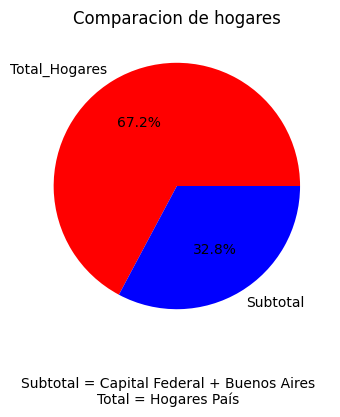

In [28]:
# Grafico en Torta: Hipotesis 1 ##
    #Listas#
valores = [12171675 , 5939618]
etiquetas = ['Total_Hogares' , 'Subtotal']
plt.figure(figsize = (7 , 4)) # Tamaño 
plt.pie(valores , labels = etiquetas, autopct='%1.1f%%' , colors = ['red' , 'blue'])
plt.title("Comparacion de hogares")
# Comentario aclaratorio debajo del gráfico
plt.figtext(0.5, -0.05, "Subtotal = Capital Federal + Buenos Aires\nTotal = Hogares País", ha="center", fontsize=10)

([<matplotlib.patches.Wedge at 0x29b4de95a90>,
 [Text(0.6935463979297374, 0.8538110996694097, 'Chubut'),
  Text(-0.800641491507185, 0.7543031234703661, 'La Pampa'),
  Text(-0.7547260859696425, -0.8002427976289096, 'Neuquén'),
  Text(0.6812041736763051, -0.8636902649480209, 'Santa Cruz'),
  Text(1.0734262416616676, -0.24032499602019644, 'Tierra del Fuego')],
 [Text(0.37829803523440214, 0.4657151452742234, '28.3%'),
  Text(-0.43671354082210084, 0.41143806734747235, '19.4%'),
  Text(-0.4116687741652595, -0.4364960714339507, '30.6%'),
  Text(0.37156591291434826, -0.4711037808807386, '14.7%'),
  Text(0.5855052227245459, -0.13108636146556168, '7.0%')])

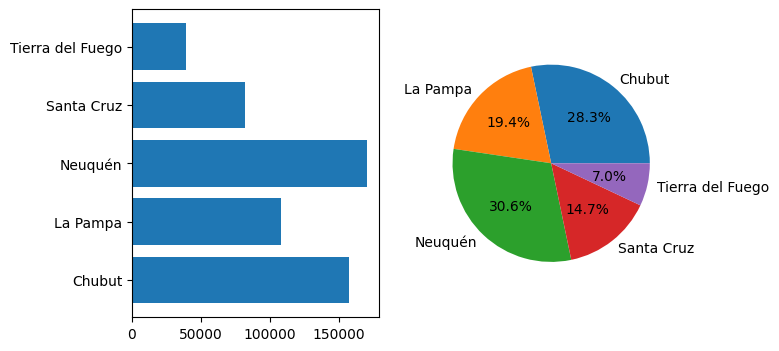

In [37]:
# Cantidad de Hogares # 
plt.figure(figsize=(7,4))
plt.subplot(1,2,1 )
plt.barh(y=patagonia['provincia'] , width=patagonia['hogares'])

plt.subplot(1,2,2)
plt.pie(patagonia['hogares'] , labels = patagonia['provincia'] ,autopct='%1.1f%%')

([<matplotlib.patches.Wedge at 0x29b4e169090>,
 [Text(0.7086671400426118, 0.8413030872544244, 'Chubut'),
  Text(-0.8060008133343427, 0.7485737698479544, 'La Pampa'),
  Text(-0.7252166757522169, -0.827079665576965, 'Neuquén'),
  Text(0.6978423889836691, -0.8503034753178219, 'Santa Cruz'),
  Text(1.0753427271518685, -0.23159883238389228, 'Tierra del Fuego')],
 [Text(0.38654571275051547, 0.4588925930478678, '27.7%'),
  Text(-0.4396368072732778, 0.40831296537161144, '20.7%'),
  Text(-0.39557273222848194, -0.45113436304198085, '30.2%'),
  Text(0.3806413030820013, -0.46380189562790275, '14.6%'),
  Text(0.5865505784464736, -0.1263266358457594, '6.8%')])

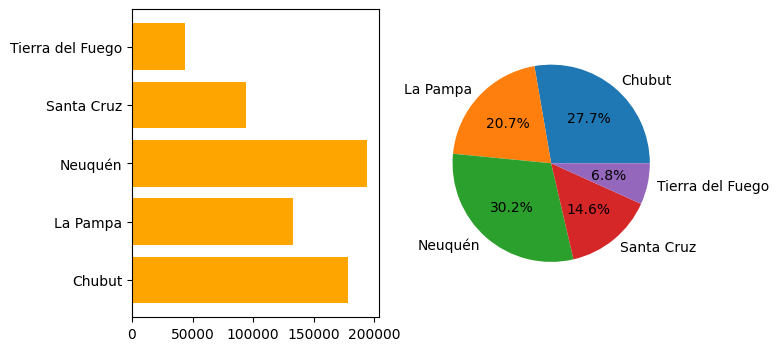

In [43]:
# Cantidad de VIVIENDAS PARTICULARES #
plt.figure(figsize=(7,4))
plt.subplot(1,2,1 )
plt.barh(y=patagonia['provincia'] , width=patagonia['viviendas_particulares'] , color = 'orange')

plt.subplot(1,2,2)
plt.pie(patagonia['viviendas_particulares'] , labels = patagonia['provincia'] ,autopct='%1.1f%%')


([<matplotlib.patches.Wedge at 0x29b4e2091d0>,
 [Text(0.6991282577931004, 0.849246536145532, 'Chubut'),
  Text(-0.8052838714763098, 0.7493449715185434, 'La Pampa'),
  Text(-0.7396367676199523, -0.8142097100776365, 'Neuquén'),
  Text(0.6866609386426477, -0.8593583393104406, 'Santa Cruz'),
  Text(1.0735153233951111, -0.23992676056640708, 'Tierra del Fuego')],
 [Text(0.3813426860689638, 0.46322538335210833, '28.1%'),
  Text(-0.4392457480779871, 0.40873362082829634, '20.0%'),
  Text(-0.4034382368836103, -0.4441143873150744, '30.4%'),
  Text(0.3745423301687169, -0.46874091235114934, '14.5%'),
  Text(0.5855538127609696, -0.1308691421271311, '7.0%')])

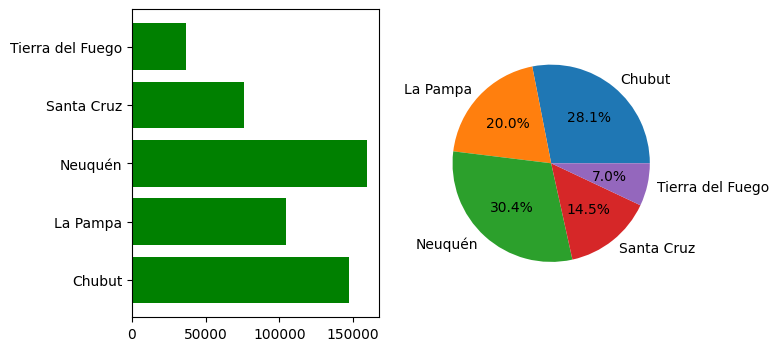

In [44]:
# VIVIENDAS PARTICULARES HABITADAS
plt.figure(figsize=(7,4))
plt.subplot(1,2,1 )
plt.barh(y=patagonia['provincia'] , width=patagonia['viviendas_particulares_habitadas'] , color = 'green')

plt.subplot(1,2,2)
plt.pie(patagonia['viviendas_particulares_habitadas'] , labels = patagonia['provincia'] ,autopct='%1.1f%%')
